In [19]:
# =============
# PCA Tutorial
# =============
# 1.Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [21]:
# 2. Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names


In [5]:
# Convert to DataFrame for easier visualisation
df = pd.DataFrame(X, columns=feature_names)
df['species'] = [target_names[i] for i in y]

print("First 5 rows of the dataset:")
print(df.head())


First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


In [23]:
# 3. Standardise the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


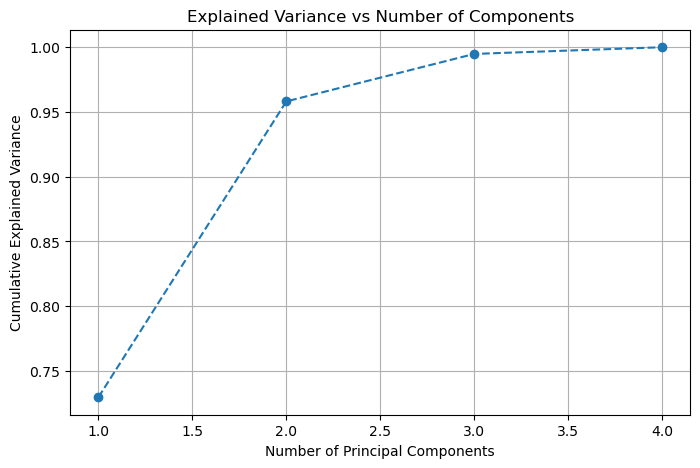

In [35]:
# 4. Apply PCA with all components to check explained variance
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', linestyle='--')
plt.title("Explained Variance vs Number of Components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()


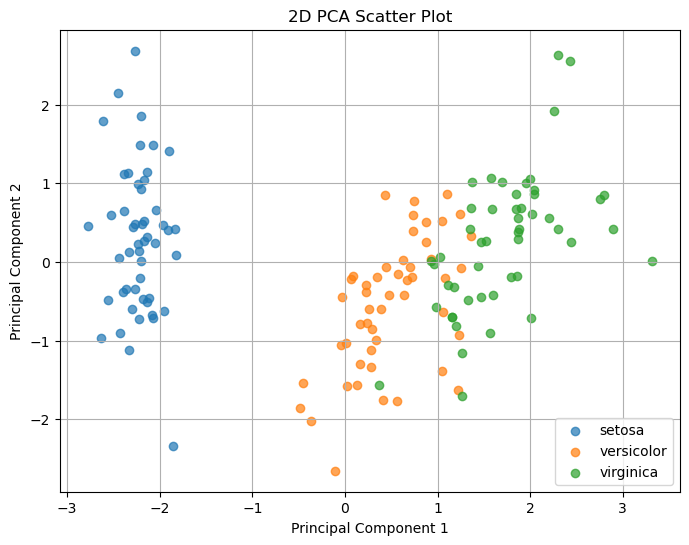

In [27]:
# 5. PCA Scatter Plot (2D)
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
for species, color in zip(range(3), ['r','g','b']):
    plt.scatter(X_pca_2d[y==species,0], X_pca_2d[y==species,1], label=target_names[species], alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Scatter Plot")
plt.legend()
plt.grid(True)
plt.show()


In [29]:
# 6. Evaluate classification performance vs number of components
accuracy_list = []
component_range = range(1, X_scaled.shape[1]+1)

for n_components in component_range:
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)
    
    # Logistic Regression
    clf = LogisticRegression(max_iter=200)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_list.append(accuracy)


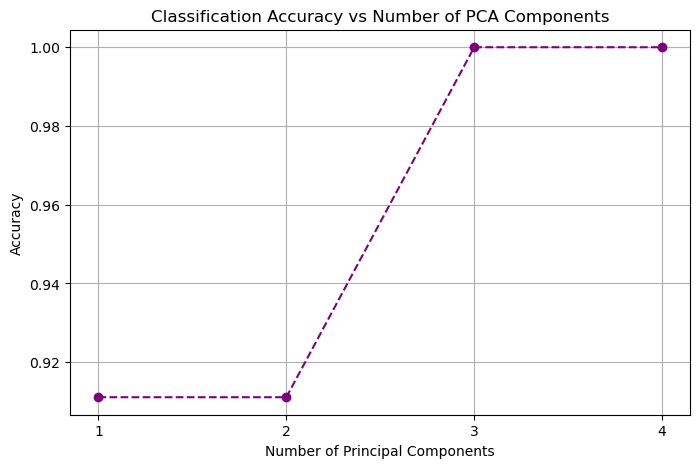

In [15]:
# Plot accuracy vs components
plt.figure(figsize=(8,5))
plt.plot(component_range, accuracy_list, marker='o', linestyle='--', color='purple')
plt.title("Classification Accuracy vs Number of PCA Components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Accuracy")
plt.xticks(component_range)
plt.grid(True)
plt.show()


In [31]:
# 7. Print results
for n, acc in zip(component_range, accuracy_list):
    print(f"Components: {n} -> Accuracy: {acc:.4f}")

Components: 1 -> Accuracy: 0.9111
Components: 2 -> Accuracy: 0.9111
Components: 3 -> Accuracy: 1.0000
Components: 4 -> Accuracy: 1.0000
